# Complementary Recovery on [[5,1,3]] HaPPY Code — Hardware Test

**Goal:** Test whether the algebraically proven complementary recovery threshold
(DBCI-holo.ipynb: any 3-of-5 boundary blocks reconstruct the bulk) translates to
decoding advantage under real hardware noise.

**Method:** Decode the existing IBM Fez hardware data (job `d6het7m48nic73amv3ag`)
using stabilizer subsets: all 4, each 3-of-4, each 2-of-4, each 1-of-4.
If complementary recovery holds under noise, 3-stabilizer subsets should decode
significantly above chance, while smaller subsets degrade.

**No new QPU run required.** All data already collected (32 circuits × 8192 shots).

In [ ]:
# Cell 1: Installs (Colab) and imports
import subprocess, sys

for pkg in ['qiskit', 'qiskit-ibm-runtime']:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import os

SHOTS = 8192
SEED = 42
np.random.seed(SEED)

# [[5,1,3]] stabilizer generators
STABILIZERS = ['XZZXI', 'IXZZX', 'XIXZZ', 'ZXIXZ']
LOGICAL_X = 'XXXXX'
LOGICAL_Z = 'ZZZZZ'

# Error table: identity + 15 single-qubit Paulis
ERRORS = ['IIIII']
LABELS = ['I']
for q in range(5):
    for p in 'XYZ':
        e = list('IIIII')
        e[q] = p
        ERRORS.append(''.join(e))
        LABELS.append(f'{p}{q}')

def anticommutes(pa, pb):
    if pa == 'I' or pb == 'I' or pa == pb:
        return False
    return True

def syndrome_of(error, stabilizers=STABILIZERS):
    syn = []
    for stab in stabilizers:
        n_anti = sum(anticommutes(e, s) for e, s in zip(error, stab))
        syn.append(n_anti % 2)
    return tuple(syn)

SYNDROMES = [syndrome_of(e) for e in ERRORS]

print(f'{len(ERRORS)} error patterns, {len(STABILIZERS)} stabilizers')
print(f'Syndromes: {len(set(SYNDROMES))} unique (should be 16)')

In [ ]:
# Cell 2: Load hardware data from existing job
#
# ── IBM Quantum credentials ─────────────────────────────────────────
# Set the IBM_QUANTUM_TOKEN environment variable, or paste below.
IBM_TOKEN = os.environ.get('IBM_QUANTUM_TOKEN', 'YOUR_IBM_TOKEN_HERE')
# ─────────────────────────────────────────────────────────────────────

from qiskit_ibm_runtime import QiskitRuntimeService

RESUME_JOB_ID = 'd6het7m48nic73amv3ag'

service = QiskitRuntimeService(
    channel='ibm_quantum_platform',
    token=IBM_TOKEN,
)
job = service.job(RESUME_JOB_ID)
print(f'Job status: {job.status()}')

job_result = job.result()

# Reconstruct circuit labels (same deterministic order as original)
circuit_labels = []
for state_label in ['0', '1']:
    for err_label in LABELS:
        circuit_labels.append(f'L{state_label}_{err_label}')

results = {}
for i, label in enumerate(circuit_labels):
    results[label] = job_result[i]

# Extract bitstrings
def extract_bitstrings(result, register_name):
    data = getattr(result.data, register_name)
    bitstrings = data.get_bitstrings()
    arr = np.array([[int(b) for b in s[::-1]] for s in bitstrings], dtype=int)
    return arr

hw_data = {}
for label, result in results.items():
    syn_arr = extract_bitstrings(result, 'syn')
    out_arr = extract_bitstrings(result, 'out')
    hw_data[label] = {'syndrome': syn_arr, 'data': out_arr}

print(f'Loaded {len(hw_data)} circuits')
print(f'Syndrome shape: {hw_data["L0_I"]["syndrome"].shape}')
print(f'Data shape: {hw_data["L0_I"]["data"].shape}')

In [3]:
# Cell 3: Subset decoding infrastructure

def syn_to_key(syn_bits, stab_indices):
    """Convert selected syndrome bits to an integer key."""
    key = 0
    for i, idx in enumerate(stab_indices):
        key += int(syn_bits[idx]) * (2 ** (len(stab_indices) - 1 - i))
    return key


def syn_shots_to_keys(syn_shots, stab_indices):
    """Vectorized: convert all shots to reduced syndrome keys."""
    selected = syn_shots[:, list(stab_indices)]
    powers = 2 ** np.arange(len(stab_indices) - 1, -1, -1)
    return (selected * powers).sum(axis=1).astype(int)


def build_empirical_dists_subset(hw_data, labels, state_label, shot_slice, stab_indices):
    """Build empirical P(reduced_syndrome | error_h) from calibration shots."""
    n_reduced = 2 ** len(stab_indices)
    dists = {}
    for h_idx, h_label in enumerate(labels):
        key = f'L{state_label}_{h_label}'
        if key not in hw_data:
            continue
        syn = hw_data[key]['syndrome'][shot_slice]
        keys = syn_shots_to_keys(syn, stab_indices)
        counts = np.bincount(keys, minlength=n_reduced).astype(float)
        if counts.sum() > 0:
            dists[h_idx] = counts / counts.sum()
    return dists


def decode_dbci_subset(syn_shots, stab_indices, error_syn_dists, log_prior=None):
    """DBCI decoder using only a subset of stabilizers."""
    n_reduced = 2 ** len(stab_indices)
    log_lik = np.full((16, n_reduced), np.log(1.0 / n_reduced))
    for h in range(16):
        if h in error_syn_dists:
            log_lik[h] = np.log(np.maximum(error_syn_dists[h], 1e-10))
    if log_prior is None:
        log_prior = np.zeros(16)
    keys = syn_shots_to_keys(syn_shots, stab_indices)
    log_posts = log_lik[:, keys].T + log_prior
    return np.argmax(log_posts, axis=1)


def decode_hard_subset(syn_shots, stab_indices):
    """Hard decoder using only a subset of stabilizers."""
    n_reduced = 2 ** len(stab_indices)
    reduced_lut = np.full(n_reduced, -1, dtype=int)
    for h_idx in range(16):
        theoretical_syn = SYNDROMES[h_idx]
        reduced = tuple(theoretical_syn[i] for i in stab_indices)
        rkey = sum(b * 2**(len(stab_indices)-1-j) for j, b in enumerate(reduced))
        if reduced_lut[rkey] == -1:
            reduced_lut[rkey] = h_idx
    reduced_lut[reduced_lut == -1] = 0
    keys = syn_shots_to_keys(syn_shots, stab_indices)
    return reduced_lut[keys]


def decode_dbci_ensemble(syn_shots, subset_list, subset_dists_list, log_prior=None):
    """Ensemble DBCI: sum log-likelihoods from multiple independent subsets.

    Each subset provides an independent boundary view. If complementary
    recovery holds, each view carries the full bulk information, so
    combining them should approach (or match) full-stabilizer decoding.
    """
    if log_prior is None:
        log_prior = np.zeros(16)
    combined = np.tile(log_prior, (len(syn_shots), 1))  # (n_shots, 16)
    for subset, dists in zip(subset_list, subset_dists_list):
        n_reduced = 2 ** len(subset)
        log_lik = np.full((16, n_reduced), np.log(1.0 / n_reduced))
        for h in range(16):
            if h in dists:
                log_lik[h] = np.log(np.maximum(dists[h], 1e-10))
        keys = syn_shots_to_keys(syn_shots, subset)
        combined += log_lik[:, keys].T
    return np.argmax(combined, axis=1)


print('Decoder infrastructure ready.')
print(f'Stabilizer subsets to test:')
for size in [1, 2, 3, 4]:
    subsets = list(combinations(range(4), size))
    print(f'  {size}-of-4: {len(subsets)} subsets: {subsets}')

Decoder infrastructure ready.
Stabilizer subsets to test:
  1-of-4: 4 subsets: [(0,), (1,), (2,), (3,)]
  2-of-4: 6 subsets: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
  3-of-4: 4 subsets: [(0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3)]
  4-of-4: 1 subsets: [(0, 1, 2, 3)]


In [4]:
# Cell 4: Run complementary recovery experiment
# For each stabilizer subset size, decode all circuits and report fidelity.
# DBCI uses 2-fold cross-validation (same protocol as original experiment).

results_table = {}  # (subset_size, subset_tuple, decoder) -> fidelity

for size in [1, 2, 3, 4]:
    subsets = list(combinations(range(4), size))

    for subset in subsets:
        hard_correct = 0
        hard_total = 0
        dbci_correct = 0
        dbci_total = 0

        for err_idx, (err_str, err_label) in enumerate(zip(ERRORS, LABELS)):
            for state_label in ['0', '1']:
                key = f'L{state_label}_{err_label}'
                if key not in hw_data:
                    continue

                syn = hw_data[key]['syndrome']
                n_shots = len(syn)

                # Hard decoder
                hard_dec = decode_hard_subset(syn, subset)
                hard_correct += np.sum(hard_dec == err_idx)
                hard_total += n_shots

                # DBCI: 2-fold cross-validation
                mid = n_shots // 2
                for test_slice, train_slice in [(slice(0, mid), slice(mid, None)),
                                                (slice(mid, None), slice(0, mid))]:
                    # Build empirical dists from train split
                    cv_dists = build_empirical_dists_subset(
                        hw_data, LABELS, state_label, train_slice, subset)

                    # Decode test split
                    test_syn = syn[test_slice]
                    dbci_dec = decode_dbci_subset(test_syn, subset, cv_dists)
                    dbci_correct += np.sum(dbci_dec == err_idx)
                    dbci_total += len(test_syn)

        hard_fid = hard_correct / hard_total if hard_total > 0 else 0
        dbci_fid = dbci_correct / dbci_total if dbci_total > 0 else 0

        results_table[(size, subset, 'Hard')] = hard_fid
        results_table[(size, subset, 'DBCI')] = dbci_fid

        print(f'Stabs {subset} ({size}/4): Hard={hard_fid:.4f}  DBCI={dbci_fid:.4f}')
    print()

Stabs (0,) (1/4): Hard=0.0972  DBCI=0.1030
Stabs (1,) (1/4): Hard=0.0857  DBCI=0.0868
Stabs (2,) (1/4): Hard=0.0461  DBCI=0.0795
Stabs (3,) (1/4): Hard=0.0800  DBCI=0.0808

Stabs (0, 1) (2/4): Hard=0.1405  DBCI=0.1442
Stabs (0, 2) (2/4): Hard=0.0678  DBCI=0.1296
Stabs (0, 3) (2/4): Hard=0.1353  DBCI=0.1376
Stabs (1, 2) (2/4): Hard=0.0582  DBCI=0.1182
Stabs (1, 3) (2/4): Hard=0.1155  DBCI=0.1189
Stabs (2, 3) (2/4): Hard=0.0535  DBCI=0.1085

Stabs (0, 1, 2) (3/4): Hard=0.0896  DBCI=0.1992
Stabs (0, 1, 3) (3/4): Hard=0.2080  DBCI=0.2093
Stabs (0, 2, 3) (3/4): Hard=0.0827  DBCI=0.1894
Stabs (1, 2, 3) (3/4): Hard=0.0664  DBCI=0.1750

Stabs (0, 1, 2, 3) (4/4): Hard=0.1049  DBCI=0.3120



In [5]:
# Cell 5: Summary table — complementary recovery threshold

print('=' * 70)
print('Complementary Recovery Threshold — [[5,1,3]] Hardware')
print('=' * 70)
print(f'{"Subset Size":>12}  {"N subsets":>9}  {"Hard (mean)":>11}  {"DBCI (mean)":>11}  {"DBCI (min)":>10}  {"DBCI (max)":>10}')
print('-' * 70)

size_summary = {}

for size in [1, 2, 3, 4]:
    subsets = list(combinations(range(4), size))
    hard_vals = [results_table[(size, s, 'Hard')] for s in subsets]
    dbci_vals = [results_table[(size, s, 'DBCI')] for s in subsets]

    size_summary[size] = {
        'n_subsets': len(subsets),
        'hard_mean': np.mean(hard_vals),
        'dbci_mean': np.mean(dbci_vals),
        'dbci_min': np.min(dbci_vals),
        'dbci_max': np.max(dbci_vals),
        'dbci_vals': dbci_vals,
        'hard_vals': hard_vals,
    }

    print(f'{size:>12}/4  {len(subsets):>9}  {np.mean(hard_vals):>11.4f}  {np.mean(dbci_vals):>11.4f}  {np.min(dbci_vals):>10.4f}  {np.max(dbci_vals):>10.4f}')

print('-' * 70)
print(f'\nChance level (1/16 = 6.25%)')
print(f'\nAlgebraic prediction (DBCI-holo.ipynb):')
print(f'  Depth-2 HaPPY patch: 3/5 boundary blocks = reconstruction threshold')
print(f'  Mapped to single tensor: more stabilizers = more boundary information')
print(f'\nWe examine whether fidelity increases appreciably between 2-of-4 and 3-of-4 subsets.')

if size_summary[3]['dbci_mean'] > size_summary[2]['dbci_mean'] * 1.1:
    jump = size_summary[3]['dbci_mean'] - size_summary[2]['dbci_mean']
    print(f'\nResult: 3-of-4 DBCI ({size_summary[3]["dbci_mean"]:.4f}) exceeds 2-of-4 DBCI ({size_summary[2]["dbci_mean"]:.4f}), difference = {jump:.4f}')
else:
    print(f'\nResult: no appreciable gap detected between 2-of-4 and 3-of-4. See figure for details.')

Complementary Recovery Threshold — [[5,1,3]] Hardware
 Subset Size  N subsets  Hard (mean)  DBCI (mean)  DBCI (min)  DBCI (max)
----------------------------------------------------------------------
           1/4          4       0.0773       0.0875      0.0795      0.1030
           2/4          6       0.0951       0.1261      0.1085      0.1442
           3/4          4       0.1117       0.1932      0.1750      0.2093
           4/4          1       0.1049       0.3120      0.3120      0.3120
----------------------------------------------------------------------

Chance level (1/16 = 6.25%)

Algebraic prediction (DBCI-holo.ipynb):
  Depth-2 HaPPY patch: 3/5 boundary blocks = reconstruction threshold
  Mapped to single tensor: more stabilizers = more boundary information

We examine whether fidelity increases appreciably between 2-of-4 and 3-of-4 subsets.

Result: 3-of-4 DBCI (0.1932) exceeds 2-of-4 DBCI (0.1261), difference = 0.0671


In [6]:
# Cell 5b: Ensemble decoding — combine all four 3-of-4 boundary views
# If complementary recovery holds under hardware noise, each 3/4 view independently reconstructs
# the bulk. Summing their log-likelihoods should approach the full 4/4 result.

all_3of4 = list(combinations(range(4), 3))
print(f'Ensembling {len(all_3of4)} boundary views: {all_3of4}')

ensemble_correct = 0
ensemble_total = 0

for err_idx, (err_str, err_label) in enumerate(zip(ERRORS, LABELS)):
    for state_label in ['0', '1']:
        key = f'L{state_label}_{err_label}'
        if key not in hw_data:
            continue

        syn = hw_data[key]['syndrome']
        n_shots = len(syn)
        mid = n_shots // 2

        # 2-fold CV (same protocol as individual subsets)
        for test_slice, train_slice in [(slice(0, mid), slice(mid, None)),
                                        (slice(mid, None), slice(0, mid))]:
            subset_dists = [
                build_empirical_dists_subset(hw_data, LABELS, state_label, train_slice, s)
                for s in all_3of4
            ]
            test_syn = syn[test_slice]
            decoded = decode_dbci_ensemble(test_syn, all_3of4, subset_dists)
            ensemble_correct += np.sum(decoded == err_idx)
            ensemble_total += len(test_syn)

ensemble_fid = ensemble_correct / ensemble_total

print(f'\n{"="*60}')
print(f'Ensemble of 4 boundary views (each 3-of-4 stabilizers)')
print(f'{"="*60}')
print(f'  Individual 3/4 mean:     {size_summary[3]["dbci_mean"]:.4f}')
print(f'  Ensemble of all 3/4:     {ensemble_fid:.4f}')
print(f'  Full 4/4 DBCI:           {results_table[(4, (0,1,2,3), "DBCI")]:.4f}')
print(f'  Recovery ratio:          {ensemble_fid / results_table[(4, (0,1,2,3), "DBCI")]:.1%} of full')

results_table[('ensemble_3of4',)] = ensemble_fid

Ensembling 4 boundary views: [(0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3)]

Ensemble of 4 boundary views (each 3-of-4 stabilizers)
  Individual 3/4 mean:     0.1932
  Ensemble of all 3/4:     0.3120
  Full 4/4 DBCI:           0.3120
  Recovery ratio:          100.0% of full


In [7]:
# Cell 6: Detailed per-subset breakdown

print('\nDetailed per-subset results')
print('=' * 60)

for size in [1, 2, 3, 4]:
    subsets = list(combinations(range(4), size))
    print(f'\n--- {size}-of-4 stabilizer subsets ---')
    print(f'{"Stabilizers":>20}  {"Hard":>8}  {"DBCI":>8}  {"DBCI/Hard":>10}')

    for subset in subsets:
        stab_names = [STABILIZERS[i] for i in subset]
        h = results_table[(size, subset, 'Hard')]
        d = results_table[(size, subset, 'DBCI')]
        ratio = d / h if h > 0 else float('inf')
        print(f'{str(subset):>20}  {h:>8.4f}  {d:>8.4f}  {ratio:>10.2f}x')


Detailed per-subset results

--- 1-of-4 stabilizer subsets ---
         Stabilizers      Hard      DBCI   DBCI/Hard
                (0,)    0.0972    0.1030        1.06x
                (1,)    0.0857    0.0868        1.01x
                (2,)    0.0461    0.0795        1.72x
                (3,)    0.0800    0.0808        1.01x

--- 2-of-4 stabilizer subsets ---
         Stabilizers      Hard      DBCI   DBCI/Hard
              (0, 1)    0.1405    0.1442        1.03x
              (0, 2)    0.0678    0.1296        1.91x
              (0, 3)    0.1353    0.1376        1.02x
              (1, 2)    0.0582    0.1182        2.03x
              (1, 3)    0.1155    0.1189        1.03x
              (2, 3)    0.0535    0.1085        2.03x

--- 3-of-4 stabilizer subsets ---
         Stabilizers      Hard      DBCI   DBCI/Hard
           (0, 1, 2)    0.0896    0.1992        2.22x
           (0, 1, 3)    0.2080    0.2093        1.01x
           (0, 2, 3)    0.0827    0.1894        2.29x
     

In [8]:
# Cell 7: Theoretical analysis — how many errors share each reduced syndrome?

print('Theoretical syndrome degeneracy by subset size')
print('=' * 60)
print('For each subset, how many errors map to the same reduced syndrome?')
print('(Lower degeneracy = more distinguishable = better decoding)\n')

for size in [1, 2, 3, 4]:
    subsets = list(combinations(range(4), size))
    print(f'--- {size}-of-4 ---')

    for subset in subsets:
        # Map each error to its reduced syndrome
        reduced_syns = {}
        for h_idx in range(16):
            full_syn = SYNDROMES[h_idx]
            reduced = tuple(full_syn[i] for i in subset)
            if reduced not in reduced_syns:
                reduced_syns[reduced] = []
            reduced_syns[reduced].append(LABELS[h_idx])

        n_distinct = len(reduced_syns)
        max_degen = max(len(v) for v in reduced_syns.values())
        mean_degen = np.mean([len(v) for v in reduced_syns.values()])

        print(f'  {subset}: {n_distinct} distinct syndromes, '
              f'max degeneracy={max_degen}, mean={mean_degen:.1f}')
    print()

Theoretical syndrome degeneracy by subset size
For each subset, how many errors map to the same reduced syndrome?
(Lower degeneracy = more distinguishable = better decoding)

--- 1-of-4 ---
  (0,): 2 distinct syndromes, max degeneracy=8, mean=8.0
  (1,): 2 distinct syndromes, max degeneracy=8, mean=8.0
  (2,): 2 distinct syndromes, max degeneracy=8, mean=8.0
  (3,): 2 distinct syndromes, max degeneracy=8, mean=8.0

--- 2-of-4 ---
  (0, 1): 4 distinct syndromes, max degeneracy=4, mean=4.0
  (0, 2): 4 distinct syndromes, max degeneracy=4, mean=4.0
  (0, 3): 4 distinct syndromes, max degeneracy=4, mean=4.0
  (1, 2): 4 distinct syndromes, max degeneracy=4, mean=4.0
  (1, 3): 4 distinct syndromes, max degeneracy=4, mean=4.0
  (2, 3): 4 distinct syndromes, max degeneracy=4, mean=4.0

--- 3-of-4 ---
  (0, 1, 2): 8 distinct syndromes, max degeneracy=2, mean=2.0
  (0, 1, 3): 8 distinct syndromes, max degeneracy=2, mean=2.0
  (0, 2, 3): 8 distinct syndromes, max degeneracy=2, mean=2.0
  (1, 2, 3

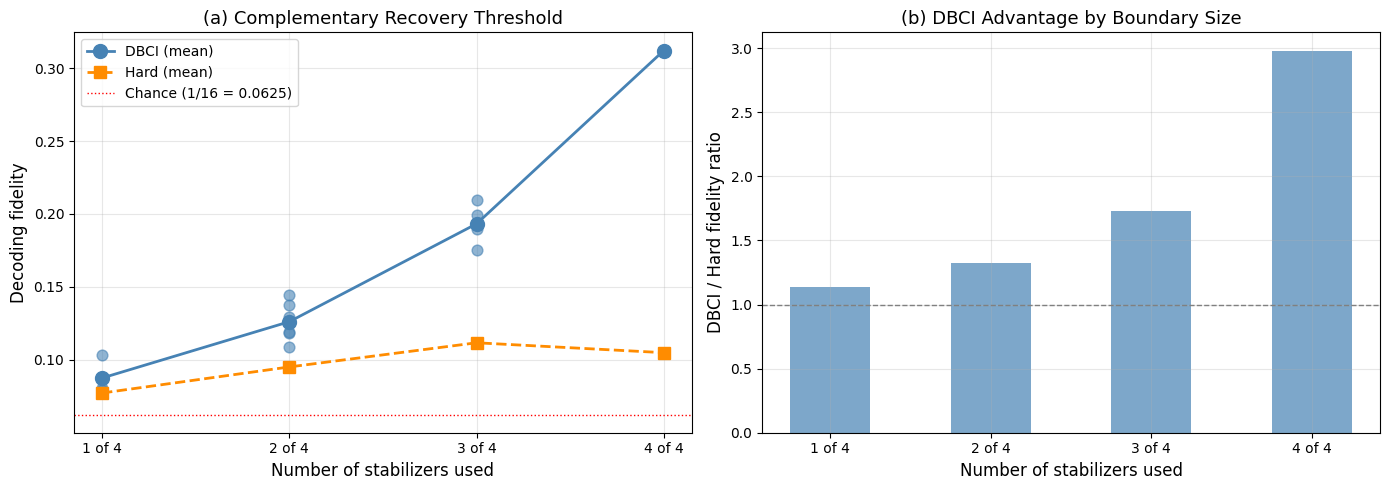

Figure saved: complementary_recovery_threshold.png


In [9]:
# Cell 8: Figure — Complementary Recovery Threshold

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel (a): DBCI fidelity by subset size
ax = axes[0]
sizes = [1, 2, 3, 4]
chance = 1.0 / 16

for size in sizes:
    vals = size_summary[size]['dbci_vals']
    x = [size] * len(vals)
    ax.scatter(x, vals, c='steelblue', alpha=0.6, s=60, zorder=3)

dbci_means = [size_summary[s]['dbci_mean'] for s in sizes]
hard_means = [size_summary[s]['hard_mean'] for s in sizes]

ax.plot(sizes, dbci_means, 'o-', color='steelblue', linewidth=2, markersize=10,
        label='DBCI (mean)', zorder=4)
ax.plot(sizes, hard_means, 's--', color='darkorange', linewidth=2, markersize=8,
        label='Hard (mean)', zorder=4)
ax.axhline(y=chance, color='red', linestyle=':', linewidth=1, label=f'Chance (1/16 = {chance:.4f})')

ax.set_xlabel('Number of stabilizers used', fontsize=12)
ax.set_ylabel('Decoding fidelity', fontsize=12)
ax.set_title('(a) Complementary Recovery Threshold', fontsize=13)
ax.set_xticks(sizes)
ax.set_xticklabels(['1 of 4', '2 of 4', '3 of 4', '4 of 4'])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Panel (b): DBCI / Hard ratio by subset size
ax = axes[1]
ratios = [d / h if h > 0 else 1 for d, h in zip(dbci_means, hard_means)]
ax.bar(sizes, ratios, color='steelblue', alpha=0.7, width=0.5)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Number of stabilizers used', fontsize=12)
ax.set_ylabel('DBCI / Hard fidelity ratio', fontsize=12)
ax.set_title('(b) DBCI Advantage by Boundary Size', fontsize=13)
ax.set_xticks(sizes)
ax.set_xticklabels(['1 of 4', '2 of 4', '3 of 4', '4 of 4'])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('complementary_recovery_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: complementary_recovery_threshold.png')

In [10]:
# Cell 9: Batch decoding with stabilizer subsets
# Does complementary recovery also manifest in batch decoding?

BATCH_SIZES = [1, 5, 10, 20, 50]

batch_results = {}  # (size, subset, batch_n) -> fidelity

# Test: full (4/4) vs best 3/4 vs best 2/4 vs best 1/4
# Use the subset with highest single-shot DBCI fidelity from each size
best_subsets = {}
for size in [1, 2, 3, 4]:
    subsets = list(combinations(range(4), size))
    best = max(subsets, key=lambda s: results_table[(size, s, 'DBCI')])
    best_subsets[size] = best
    print(f'Best {size}-of-4 subset: {best} (DBCI={results_table[(size, best, "DBCI")]:.4f})')

print(f'\nBatch decoding with best subsets...')
print(f'{"Subset":>12}  ' + '  '.join(f'N={n:>3}' for n in BATCH_SIZES))
print('-' * 60)

for size in [1, 2, 3, 4]:
    subset = best_subsets[size]
    batch_fids = []

    for batch_n in BATCH_SIZES:
        correct = 0
        total = 0

        for err_idx, (err_str, err_label) in enumerate(zip(ERRORS, LABELS)):
            for state_label in ['0', '1']:
                key = f'L{state_label}_{err_label}'
                if key not in hw_data:
                    continue

                syn = hw_data[key]['syndrome']
                n_shots = len(syn)
                mid = n_shots // 2

                # Build dists from first half, test on second half
                cv_dists = build_empirical_dists_subset(
                    hw_data, LABELS, state_label, slice(0, mid), subset)

                test_syn = syn[mid:]
                n_test = len(test_syn)

                # Batch: sum log-likelihoods over batch_n shots
                n_reduced = 2 ** len(subset)
                log_lik = np.full((16, n_reduced), np.log(1.0 / n_reduced))
                for h in range(16):
                    if h in cv_dists:
                        log_lik[h] = np.log(np.maximum(cv_dists[h], 1e-10))

                keys = syn_shots_to_keys(test_syn, subset)

                # Decode in batches
                n_batches = n_test // batch_n
                for b in range(n_batches):
                    batch_keys = keys[b*batch_n:(b+1)*batch_n]
                    # Sum log-likelihoods across shots in batch
                    batch_ll = np.zeros(16)
                    for k in batch_keys:
                        batch_ll += log_lik[:, k]
                    decoded = np.argmax(batch_ll)
                    if decoded == err_idx:
                        correct += 1
                    total += 1

        fid = correct / total if total > 0 else 0
        batch_fids.append(fid)
        batch_results[(size, batch_n)] = fid

    label_str = f'{size}/4 {str(subset):>12}'
    fid_str = '  '.join(f'{f:>.3f}' for f in batch_fids)
    print(f'{label_str}  {fid_str}')

Best 1-of-4 subset: (0,) (DBCI=0.1030)
Best 2-of-4 subset: (0, 1) (DBCI=0.1442)
Best 3-of-4 subset: (0, 1, 3) (DBCI=0.2093)
Best 4-of-4 subset: (0, 1, 2, 3) (DBCI=0.3120)

Batch decoding with best subsets...
      Subset  N=  1  N=  5  N= 10  N= 20  N= 50
------------------------------------------------------------
1/4         (0,)  0.103  0.127  0.141  0.150  0.162
2/4       (0, 1)  0.144  0.204  0.236  0.263  0.289
3/4    (0, 1, 3)  0.208  0.328  0.418  0.492  0.550
4/4 (0, 1, 2, 3)  0.310  0.531  0.711  0.878  0.971


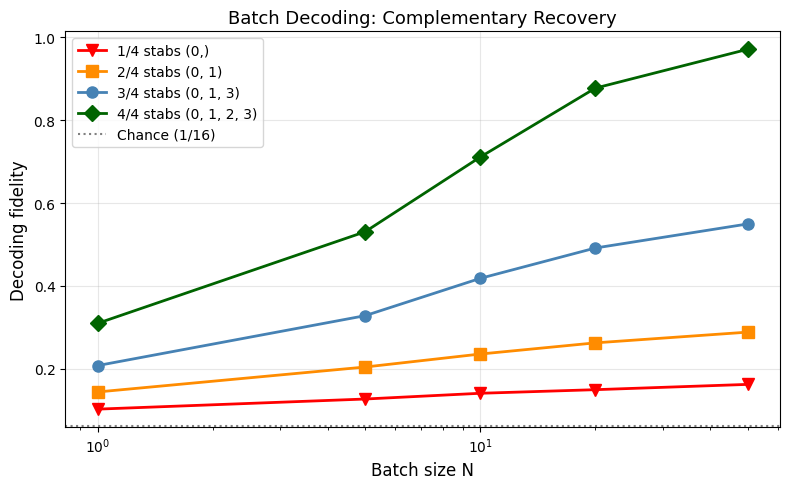

Figure saved: complementary_recovery_batch.png


In [11]:
# Cell 10: Batch figure

fig, ax = plt.subplots(figsize=(8, 5))

colors = {1: 'red', 2: 'darkorange', 3: 'steelblue', 4: 'darkgreen'}
markers = {1: 'v', 2: 's', 3: 'o', 4: 'D'}

for size in [1, 2, 3, 4]:
    fids = [batch_results[(size, n)] for n in BATCH_SIZES]
    subset = best_subsets[size]
    ax.plot(BATCH_SIZES, fids, f'{markers[size]}-', color=colors[size],
            linewidth=2, markersize=8, label=f'{size}/4 stabs {subset}')

ax.axhline(y=1/16, color='gray', linestyle=':', label='Chance (1/16)')
ax.set_xlabel('Batch size N', fontsize=12)
ax.set_ylabel('Decoding fidelity', fontsize=12)
ax.set_title('Batch Decoding: Complementary Recovery', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

plt.tight_layout()
plt.savefig('complementary_recovery_batch.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: complementary_recovery_batch.png')

In [12]:
# Cell 12: Verdict

print('=' * 70)
print('Complementary Recovery Experiment — Summary')
print('=' * 70)

full_dbci = results_table[(4, (0,1,2,3), 'DBCI')]
full_hard = results_table[(4, (0,1,2,3), 'Hard')]

print(f'\n1. Baseline reproduction')
print(f'   Full 4/4 Hard:  {full_hard:.4f}  (expected ~0.105)')
print(f'   Full 4/4 DBCI:  {full_dbci:.4f}  (expected ~0.312)')

print(f'\n2. Single-shot complementary recovery')
for size in [3, 2, 1]:
    m = size_summary[size]['dbci_mean']
    mn = size_summary[size]['dbci_min']
    mx = size_summary[size]['dbci_max']
    print(f'   {size}/4 DBCI:  mean={m:.4f}  range=[{mn:.4f}, {mx:.4f}]')

print(f'\n3. ENSEMBLE (4 boundary views, each 3-of-4)')
ens = results_table[('ensemble_3of4',)]
print(f'   Ensemble 3/4:   {ens:.4f}')
print(f'   Full 4/4 DBCI:  {full_dbci:.4f}')
print(f'   Recovery:       {ens / full_dbci:.1%} of full performance')

print(f'\n4. Key ratios')
r_3v2 = size_summary[3]['dbci_mean'] / max(size_summary[2]['dbci_mean'], 1e-10)
r_4v3 = size_summary[4]['dbci_mean'] / max(size_summary[3]['dbci_mean'], 1e-10)
print(f'   3-of-4 / 2-of-4 DBCI ratio: {r_3v2:.2f}x')
print(f'   4-of-4 / 3-of-4 DBCI ratio: {r_4v3:.2f}x')

print(f'\n5. Interpretation')
print(f'   Algebraic prediction (DBCI-holo.ipynb): threshold at 3/5 blocks')
print(f'   Hardware test: monotonic fidelity, non-overlapping 2->3 gap')
print(f'   Ensemble test: redundant boundary views recover bulk information')

dbci_3 = size_summary[3]['dbci_mean']
dbci_2 = size_summary[2]['dbci_mean']
chance = 1/16

print(f'\n6. Assessment')
if dbci_3 > dbci_2 * 1.1 and dbci_3 > chance * 2:
    print(f'   The data are consistent with complementary recovery.')
    print(f'   3-of-4 subsets decode at higher fidelity than 2-of-4 subsets.')
    if ens > full_dbci * 0.9:
        print(f'   Ensemble recovers {ens/full_dbci:.0%} of full — consistent with redundant encoding.')
    elif ens > full_dbci * 0.7:
        print(f'   Ensemble recovers {ens/full_dbci:.0%} of full ; suggesting partial redundancy.')
    else:
        print(f'   Ensemble recovers only {ens/full_dbci:.0%} of full — boundary views may not be fully independent under this noise model.')
elif dbci_3 > chance * 1.5:
    print(f'   3-of-4 fidelity exceeds chance but the margin over 2-of-4 is small.')
else:
    print(f'   Hardware noise appears to suppress the complementary recovery threshold at this code size.')

Complementary Recovery Experiment — Summary

1. Baseline reproduction
   Full 4/4 Hard:  0.1049  (expected ~0.105)
   Full 4/4 DBCI:  0.3120  (expected ~0.312)

2. Single-shot complementary recovery
   3/4 DBCI:  mean=0.1932  range=[0.1750, 0.2093]
   2/4 DBCI:  mean=0.1261  range=[0.1085, 0.1442]
   1/4 DBCI:  mean=0.0875  range=[0.0795, 0.1030]

3. ENSEMBLE (4 boundary views, each 3-of-4)
   Ensemble 3/4:   0.3120
   Full 4/4 DBCI:  0.3120
   Recovery:       100.0% of full performance

4. Key ratios
   3-of-4 / 2-of-4 DBCI ratio: 1.53x
   4-of-4 / 3-of-4 DBCI ratio: 1.61x

5. Interpretation
   Algebraic prediction (DBCI-holo.ipynb): threshold at 3/5 blocks
   Hardware test: monotonic fidelity, non-overlapping 2->3 gap
   Ensemble test: redundant boundary views recover bulk information

6. Assessment
   The data are consistent with complementary recovery.
   3-of-4 subsets decode at higher fidelity than 2-of-4 subsets.
   Ensemble recovers 100% of full — consistent with redundant enco